# Análisis de Métricas de Simplificación de Texto
Este notebook analiza los resultados de la simplificación de texto por diferentes herramientas y modelos, utilizando las métricas SARI, BLEU, BERTScore y los Índices de Legibilidad (Fernández Huerta, Inflesz y Mu).

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar los datos
df = pd.read_excel('metric.xlsx', sheet_name='Summary by Document')

# Limpiar los datos: quitar PROMEDIO
df = df[df['document_id'] != 'PROMEDIO'].copy()

# Definir grupos: Normas UNE vs Modelos
une_tools = ['FACILE', 'SimpleText (ClearText)']
df['Grupo'] = df['document_id'].apply(lambda x: 'Normas UNE' if x in une_tools else 'Modelos IA')

# Seleccionar las métricas clave para el análisis
metricas = ['sari', 'bleu', 'bertscore_f1', 'fernandez_huerta_index', 'inflesz_index', 'mu_index', 'roberta_sense_facil_preserves_meaning']

print("Datos cargados correctamente. Total de herramientas a analizar:", len(df))


Datos cargados correctamente. Total de herramientas a analizar: 16


## 1. Análisis de Modelos: AdaptaTuTexto
Comparación entre Gemini 3.1 Pro y deepseek-v3.2 en diferentes niveles (Fácil B1, Muy A2, Sencillo B2).

,document_id,LLM,Nivel,sari,bleu,bertscore_f1,fernandez_huerta_index,inflesz_index,mu_index,roberta_sense_facil_preserves_meaning
5,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,deepseek-v3.2,Muy A2,48.8119,0.1213,0.7602,106.457953,103.035401,76.79,0.9905
4,AdaptaTuTexto (deepseek-v3.2)\nFacil B1,deepseek-v3.2,Facil B1,47.1492,0.1059,0.7500,94.621537,90.975675,57.54,0.9841
6,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,deepseek-v3.2,Sencillo B2,46.2219,0.1051,0.7665,86.042847,82.121704,46.50,0.9821
1,AdaptaTuTexto (Gemini 3.1 Pro)\nMuy A2,Gemini 3.1 Pro,Muy A2,43.7974,0.0499,0.7114,110.273249,106.993569,84.16,0.9918
3,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,Gemini 3.1 Pro,Sencillo B2.1,43.0488,0.0608,0.7481,95.471482,92.007518,60.82,0.9904
0,AdaptaTuTexto (Gemini 3.1 Pro)\nFacil B1,Gemini 3.1 Pro,Facil B1,42.6044,0.0424,0.7154,101.022071,97.574231,64.69,0.9903
2,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2,Gemini 3.1 Pro,Sencillo B2,41.8832,0.0493,0.7374,93.972801,90.378690,56.98,0.9906


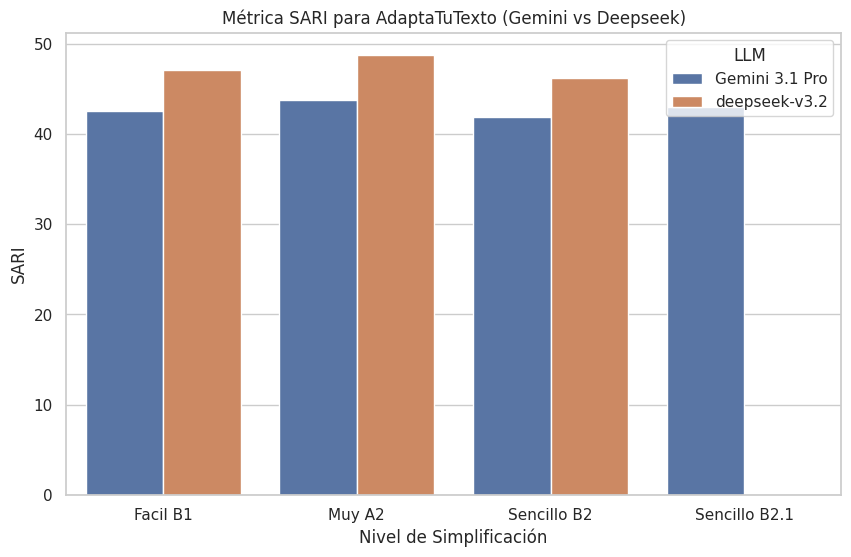

El mejor modelo de AdaptaTuTexto es: AdaptaTuTexto (deepseek-v3.2)
Muy A2


In [16]:
# Filtrar herramientas de AdaptaTuTexto
df_adapta = df[df['document_id'].str.contains('AdaptaTuTexto')].copy()

# Extraer el LLM y el nivel del nombre
df_adapta['LLM'] = df_adapta['document_id'].apply(lambda x: 'Gemini 3.1 Pro' if 'Gemini' in x else 'deepseek-v3.2')
df_adapta['Nivel'] = df_adapta['document_id'].apply(lambda x: x.split('\n')[1] if '\n' in x else x)

display(df_adapta[['document_id', 'LLM', 'Nivel'] + metricas].sort_values(by='sari', ascending=False))

# Gráfica SARI por LLM y Nivel
plt.figure(figsize=(10, 6))
sns.barplot(data=df_adapta, x='Nivel', y='sari', hue='LLM')
plt.title('Métrica SARI para AdaptaTuTexto (Gemini vs Deepseek)')
plt.ylabel('SARI')
plt.xlabel('Nivel de Simplificación')
plt.show()

# Seleccionamos el mejor de AdaptaTuTexto (basado en SARI)
mejor_adapta_id = df_adapta.sort_values(by='sari', ascending=False).iloc[0]['document_id']
print("El mejor modelo de AdaptaTuTexto es:", mejor_adapta_id)


## 2. Análisis de Modelos: Asistentes de Lectura Fácil
Comparación entre los dos asistentes personalizados.

,document_id,sari,bleu,bertscore_f1,fernandez_huerta_index,inflesz_index,mu_index,roberta_sense_facil_preserves_meaning
7,Asistente de lectura fácil “ANTONIO GONZALES C...,46.7219,0.0716,0.7321,95.402896,91.873165,53.01,0.9918
8,Asistente de lectura fácil “Mark Jonathan Cama...,47.2610,0.0921,0.7492,103.333831,99.925077,69.65,0.9903


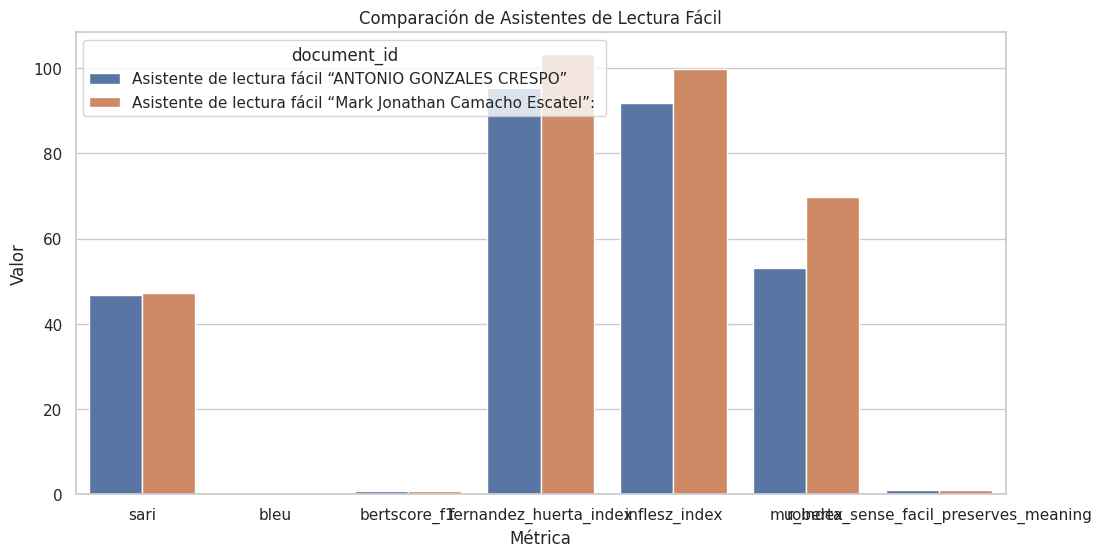

El mejor asistente es: Asistente de lectura fácil “Mark Jonathan Camacho Escatel”: 


In [17]:
df_asist = df[df['document_id'].str.contains('Asistente de lectura')].copy()
display(df_asist[['document_id'] + metricas])

# Gráfica comparativa
df_asist_melt = df_asist.melt(id_vars='document_id', value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_asist_melt, x='Métrica', y='Valor', hue='document_id')
plt.title('Comparación de Asistentes de Lectura Fácil')
plt.show()

mejor_asist_id = df_asist.sort_values(by='sari', ascending=False).iloc[0]['document_id']
print("El mejor asistente es:", mejor_asist_id)


## 3. Análisis de Modelos: Modelos Base
Comparación entre modelos puros (Claude, GPT, Gemini, Deepseek) y Placea.

,document_id,sari,bleu,bertscore_f1,fernandez_huerta_index,inflesz_index,mu_index,roberta_sense_facil_preserves_meaning
15,deepseek-v3.2,53.3765,0.1857,0.7856,100.539697,96.985611,60.53,0.9901
9,Claude Sonnet 4.6,50.2891,0.1566,0.7723,90.972359,87.469925,54.19,0.9724
11,GPT 5.4 Think,50.1571,0.1673,0.7702,89.721818,86.113788,51.20,0.9847
12,Gemini 3.1 Pro,49.3049,0.1324,0.7627,101.007134,97.590983,65.27,0.9897
13,Placea,42.1956,0.0789,0.7424,101.362804,97.970944,56.55,0.9892


/tmp/ipykernel_12677/1403771979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_base, x='document_id', y='sari', palette='viridis')


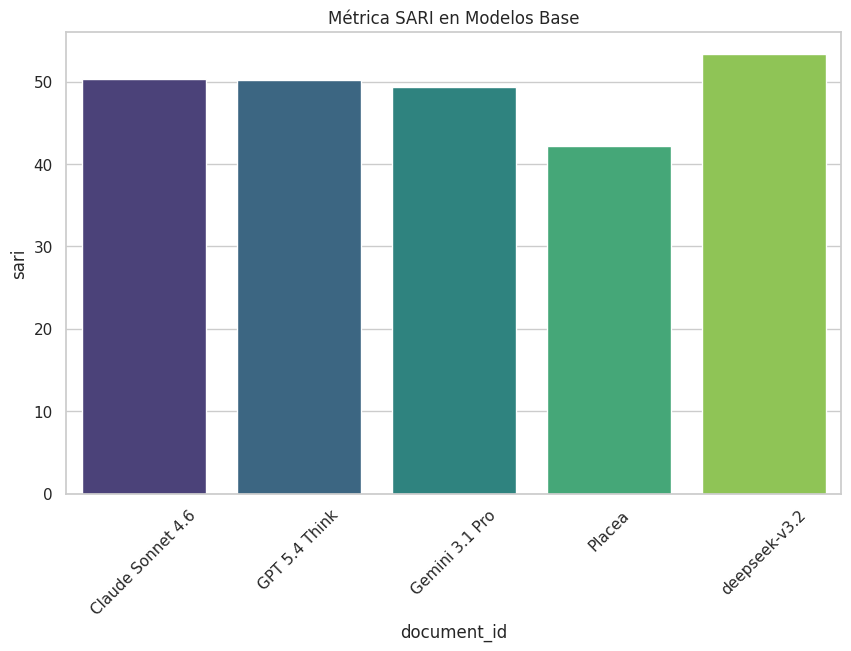

El mejor modelo base es: deepseek-v3.2


In [18]:
modelos_base_nombres = ['Claude Sonnet 4.6', 'GPT 5.4 Think', 'Gemini 3.1 Pro', 'deepseek-v3.2', 'Placea']
df_base = df[df['document_id'].isin(modelos_base_nombres)].copy()
display(df_base[['document_id'] + metricas].sort_values(by='sari', ascending=False))

# Gráfica comparativa SARI
plt.figure(figsize=(10, 6))
sns.barplot(data=df_base, x='document_id', y='sari', palette='viridis')
plt.title('Métrica SARI en Modelos Base')
plt.xticks(rotation=45)
plt.show()

mejor_base_id = df_base.sort_values(by='sari', ascending=False).iloc[0]['document_id']
print("El mejor modelo base es:", mejor_base_id)


## 4. Comparación de los Mejores Modelos de IA
Comparamos a los ganadores de cada categoría anterior.

,document_id,sari,bleu,bertscore_f1,fernandez_huerta_index,inflesz_index,mu_index,roberta_sense_facil_preserves_meaning
15,deepseek-v3.2,53.3765,0.1857,0.7856,100.539697,96.985611,60.53,0.9901
5,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,48.8119,0.1213,0.7602,106.457953,103.035401,76.79,0.9905
8,Asistente de lectura fácil “Mark Jonathan Cama...,47.2610,0.0921,0.7492,103.333831,99.925077,69.65,0.9903


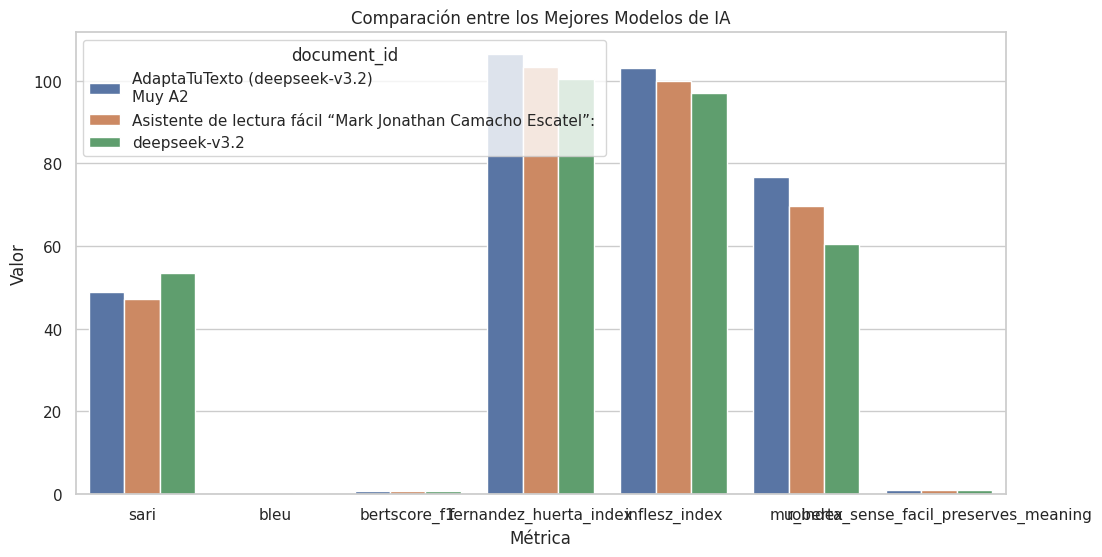

El Mejor Modelo Global de IA es: deepseek-v3.2


In [19]:
mejores_modelos_ids = [mejor_adapta_id, mejor_asist_id, mejor_base_id]
df_mejores_modelos = df[df['document_id'].isin(mejores_modelos_ids)].copy()
display(df_mejores_modelos[['document_id'] + metricas].sort_values(by='sari', ascending=False))

df_mejores_melt = df_mejores_modelos.melt(id_vars='document_id', value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_mejores_melt, x='Métrica', y='Valor', hue='document_id')
plt.title('Comparación entre los Mejores Modelos de IA')
plt.show()

el_mejor_modelo_id = df_mejores_modelos.sort_values(by='sari', ascending=False).iloc[0]['document_id']
print("El Mejor Modelo Global de IA es:", el_mejor_modelo_id)


## 5. Comparación Final: Normas UNE vs El Mejor Modelo de IA
Finalmente, comparamos el mejor enfoque basado en LLMs frente a las herramientas tradicionales basadas en normas UNE (FACILE y SimpleText).

,document_id,Grupo,sari,bleu,bertscore_f1,fernandez_huerta_index,inflesz_index,mu_index,roberta_sense_facil_preserves_meaning
15,deepseek-v3.2,Modelos IA,53.3765,0.1857,0.7856,100.539697,96.985611,60.53,0.9901
14,SimpleText (ClearText),Normas UNE,41.0793,0.1701,0.7208,78.496477,74.647884,44.95,0.9699
10,FACILE,Normas UNE,39.6624,0.1619,0.7262,80.925566,76.997419,45.42,0.9526


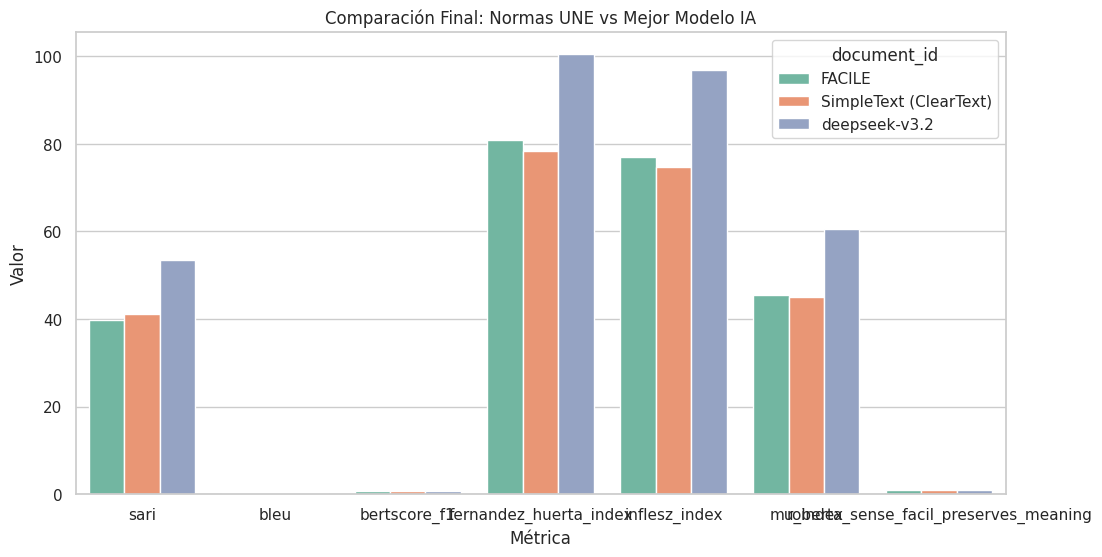

In [20]:
df_final = df[df['document_id'].isin([el_mejor_modelo_id] + une_tools)].copy()
display(df_final[['document_id', 'Grupo'] + metricas].sort_values(by='sari', ascending=False))

df_final_melt = df_final.melt(id_vars=['document_id', 'Grupo'], value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_final_melt, x='Métrica', y='Valor', hue='document_id', palette='Set2')
plt.title('Comparación Final: Normas UNE vs Mejor Modelo IA')
plt.show()


## 6. Análisis de Estabilidad y Relación con SARI
En esta sección analizamos qué tan "estables" son las herramientas. La estabilidad se define como la consistencia en el rendimiento a través de todas las métricas. 
Para esto:
1. Normalizamos todas las métricas (escala 0-1).
2. Calculamos la desviación estándar de estas métricas para cada herramienta. Una desviación baja indica mayor estabilidad (equilibrio entre calidad de simplificación, preservación semántica y legibilidad).

Herramientas ordenadas por Estabilidad (Menor Desviación Estándar = Más Estable)


,document_id,sari,estabilidad_std,promedio_norm
12,Gemini 3.1 Pro,49.3049,0.128569,0.700701
4,AdaptaTuTexto (deepseek-v3.2)\nFacil B1,47.1492,0.145455,0.520880
5,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,48.8119,0.150246,0.773125
8,Asistente de lectura fácil “Mark Jonathan Cama...,47.2610,0.205358,0.652157
15,deepseek-v3.2,53.3765,0.233525,0.819752
9,Claude Sonnet 4.6,50.2891,0.235689,0.560333
3,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,43.0488,0.265877,0.472836
6,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,46.2219,0.268349,0.417008
7,Asistente de lectura fácil “ANTONIO GONZALES C...,46.7219,0.279252,0.466806
13,Placea,42.1956,0.286665,0.503911


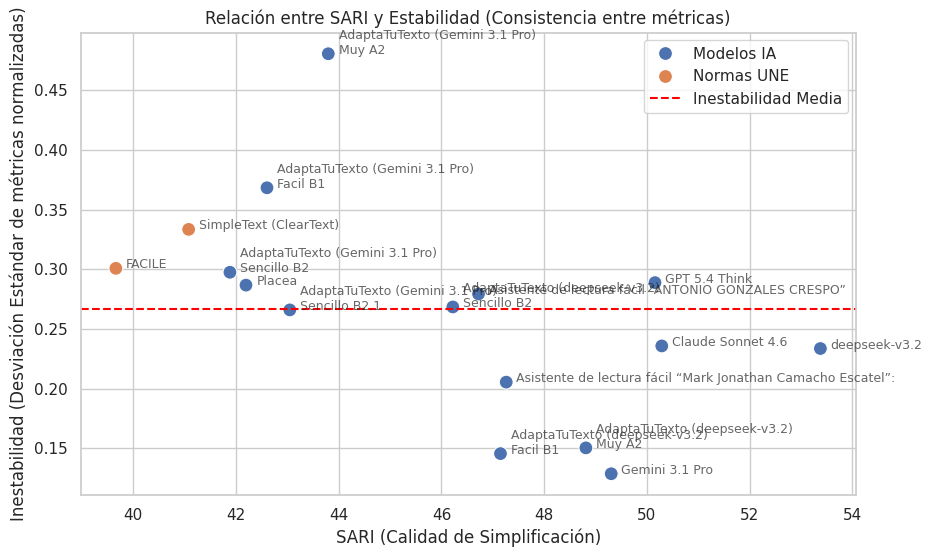

Correlación entre SARI e Inestabilidad: -0.54


In [21]:
# Normalización de métricas
df_m = df[['document_id'] + metricas].set_index('document_id')
df_norm = (df_m - df_m.min()) / (df_m.max() - df_m.min())

# Calcular Estabilidad (desviación estándar de métricas normalizadas)
# Menor desviación = Mayor estabilidad/equilibrio entre métricas
df['estabilidad_std'] = df_norm.std(axis=1).values
df['promedio_norm'] = df_norm.mean(axis=1).values

# Mostrar tabla de estabilidad
print("Herramientas ordenadas por Estabilidad (Menor Desviación Estándar = Más Estable)")
display(df[['document_id', 'sari', 'estabilidad_std', 'promedio_norm']].sort_values(by='estabilidad_std'))

# Gráfica de dispersión: SARI vs Estabilidad
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sari', y='estabilidad_std', hue='Grupo', s=100)
for i in range(df.shape[0]):
    plt.text(df.sari.iloc[i]+0.2, df.estabilidad_std.iloc[i], df.document_id.iloc[i], fontsize=9, alpha=0.7)

plt.title('Relación entre SARI y Estabilidad (Consistencia entre métricas)')
plt.xlabel('SARI (Calidad de Simplificación)')
plt.ylabel('Inestabilidad (Desviación Estándar de métricas normalizadas)')
plt.axhline(df['estabilidad_std'].mean(), color='red', linestyle='--', label='Inestabilidad Media')
plt.legend()
plt.show()

# Correlación de Pearson
corr = df[['sari', 'estabilidad_std']].corr().iloc[0,1]
print(f"Correlación entre SARI e Inestabilidad: {corr:.2f}")


## Conclusiones
*Ejecuta las celdas de arriba para ver los resultados numéricos y gráficos.*

1. **Estabilidad**: Las herramientas con menor `estabilidad_std` son aquellas que mantienen un equilibrio constante entre todas las métricas (SARI, BLEU, BERTScore y Legibilidad). Un valor alto aquí indica que la herramienta destaca mucho en algunas áreas pero falla notablemente en otras.
2. **Relación con SARI**: El gráfico de dispersión muestra si existe una tendencia donde modelos con mayor SARI tienden a ser más o menos estables. 
3. **Comparativa Final**: En general, la comparación permite identificar si el modelo de IA seleccionado supera a las herramientas estándar (Normas UNE) no solo en potencia (SARI) sino también en equilibrio (Estabilidad).
